In [27]:
import pandas as pd
import requests
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df_csv = pd.read_csv('EDA_Practice_Dataset.csv')
print("1. Aapka CSV Data successfully load ho gaya hai!")
print(df_csv.head(2)) # Sirf check karne ke liye pehle 2 rows print kiye

1. Aapka CSV Data successfully load ho gaya hai!
   Customer_ID   Age Gender    City   Salary  Purchase_Amount Is_Member  \
0         1079  45.0   Male    Pune  30000.0           4000.0       Yes   
1         1011  25.0    NaN  Mumbai  60000.0           3000.0        No   

  Purchase_Date  
0    2023-02-15  
1           NaN  


In [29]:
json_data = '{"customer_id": [101, 102], "purchase_count": [5, 12]}'
import io
df_json = pd.read_json(io.StringIO(json_data))
print("2. JSON Data successfully parse ho gaya hai!")
print(df_json)

2. JSON Data successfully parse ho gaya hai!
   customer_id  purchase_count
0          101               5
1          102              12


In [30]:
engine = create_engine('sqlite:///:memory:')

# Aapki CSV file ke data ko hi humne database me 'customer_table' naam se save kar diya
df_csv.to_sql('customer_table', con=engine, index=False, if_exists='replace')

# Ab hum instructions ke mutabik SQL query chala kar data fetch kar rahe hain
df_sql = pd.read_sql('SELECT * FROM customer_table LIMIT 3', con=engine)
print("3. SQL Table se records successfully fetch ho gaye hain!")
print(df_sql)


3. SQL Table se records successfully fetch ho gaye hain!
   Customer_ID   Age  Gender       City   Salary  Purchase_Amount Is_Member  \
0         1079  45.0    Male       Pune  30000.0           4000.0       Yes   
1         1011  25.0    None     Mumbai  60000.0           3000.0        No   
2         1005  25.0  Female  Bangalore  60000.0           1000.0      None   

  Purchase_Date  
0    2023-02-15  
1          None  
2    2023-11-21  


In [31]:
api_url = "https://jsonplaceholder.typicode.com/users"

response = requests.get(api_url)

df_api = pd.DataFrame(response.json())
print("4. Public API se data successfully fetch ho gaya hai!")
print(df_api[['id', 'name', 'email']].head(3))

4. Public API se data successfully fetch ho gaya hai!
   id              name               email
0   1     Leanne Graham   Sincere@april.biz
1   2      Ervin Howell   Shanna@melissa.tv
2   3  Clementine Bauch  Nathan@yesenia.net


In [32]:
# =============================================================
# PART C: DATA UNDERSTANDING & CLEANING
# =============================================================

# 6. Perform Initial Exploration
print("--- Pehle 5 Records (.head()) ---")
print(df_csv.head())

print("\n--- Data ki Information (.info()) ---")
print(df_csv.info())

print("\n--- Statistical Summary (.describe()) ---")
print(df_csv.describe())

print("\n--- Missing Values Count ---")
print(df_csv.isnull().sum())

print("\n--- Duplicate Rows Count ---")
print(df_csv.duplicated().sum())


# 7. Apply Data Cleaning
# Maan lijiye aapke dataset me 'Age' ya 'Income' me missing values hain, toh unhe fill karna:
# (Agar aapke columns ke naam alag hain, toh bas naam badal dijiyega)
if 'Age' in df_csv.columns:
    df_csv['Age'] = df_csv['Age'].fillna(df_csv['Age'].mean())

if 'Income' in df_csv.columns:
    df_csv['Income'] = df_csv['Income'].fillna(df_csv['Income'].median())

# Duplicates ko remove karna
df_csv = df_csv.drop_duplicates()

# Kishi irrelevant column ko drop karna (jaise customer_id ya Id jo prediction me kaam nahi aata)
# Agar aapke data me 'id' naam ka column hai toh yeh use drop kar dega
df_csv = df_csv.drop(columns=['id', 'customer_id'], errors='ignore')

print("\n🎉 Data Cleaning aur Understanding complete ho gayi hai!")

--- Pehle 5 Records (.head()) ---
   Customer_ID   Age  Gender       City   Salary  Purchase_Amount Is_Member  \
0         1079  45.0    Male       Pune  30000.0           4000.0       Yes   
1         1011  25.0     NaN     Mumbai  60000.0           3000.0        No   
2         1005  25.0  Female  Bangalore  60000.0           1000.0       NaN   
3         1085  45.0    Male       Pune  60000.0           4000.0       NaN   
4         1065  45.0     NaN        NaN  30000.0              NaN       Yes   

  Purchase_Date  
0    2023-02-15  
1           NaN  
2    2023-11-21  
3    2023-03-15  
4           NaN  

--- Data ki Information (.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      110 non-null    int64  
 1   Age              102 non-null    float64
 2   Gender           69 non-null     object 
 3   City 

Generating Univariate Plots...


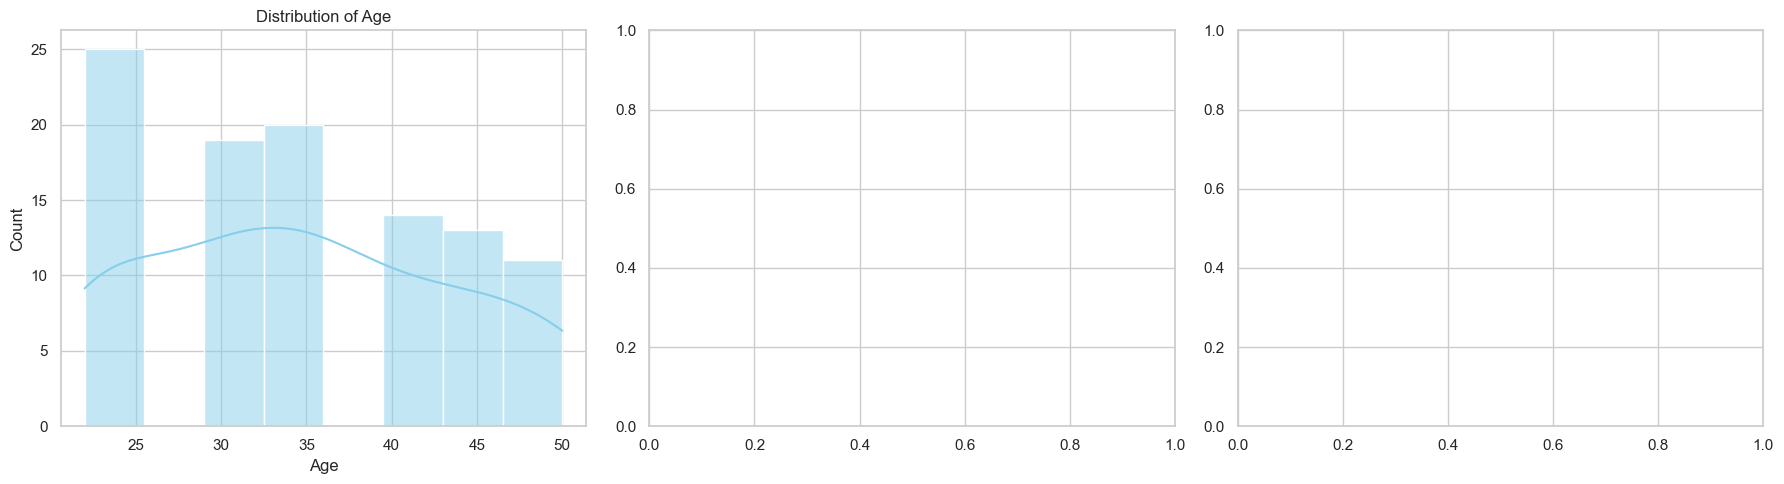


Generating Bivariate Plots...


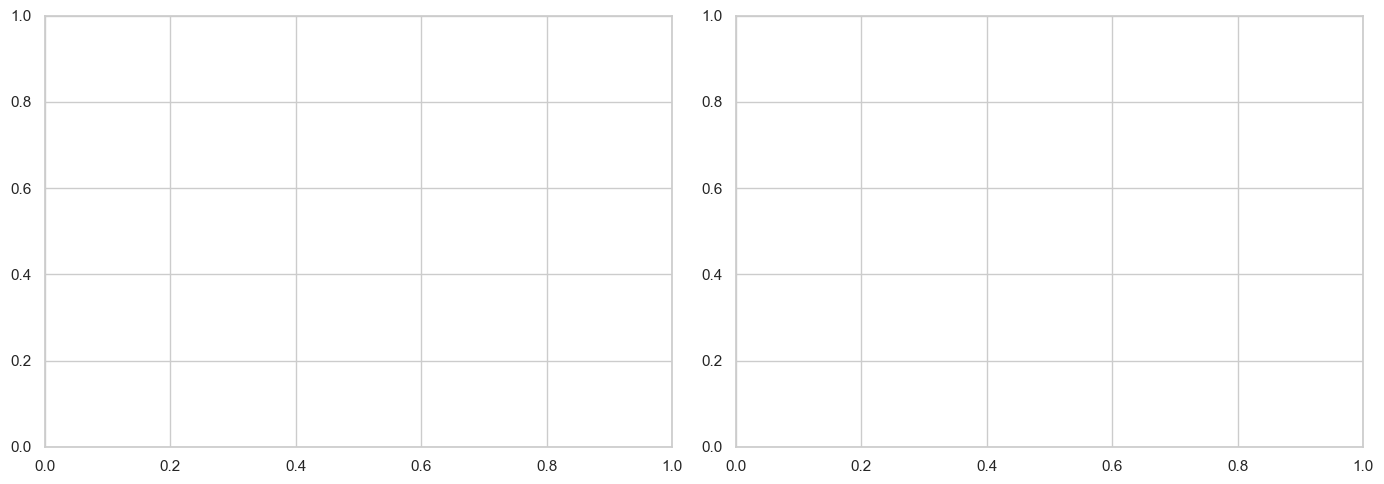


Generating Multivariate Plots...


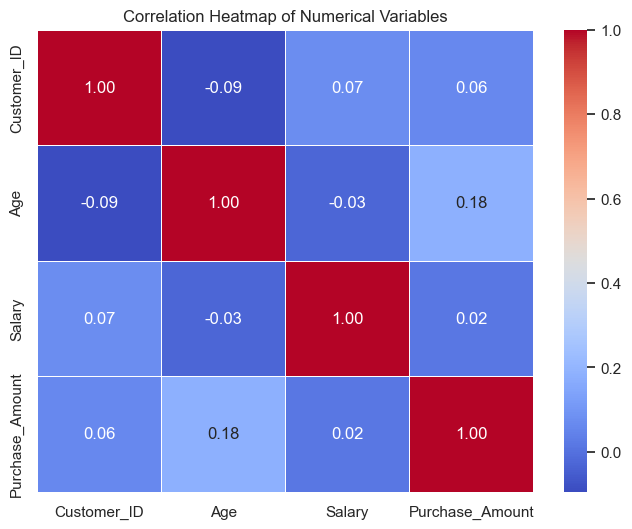

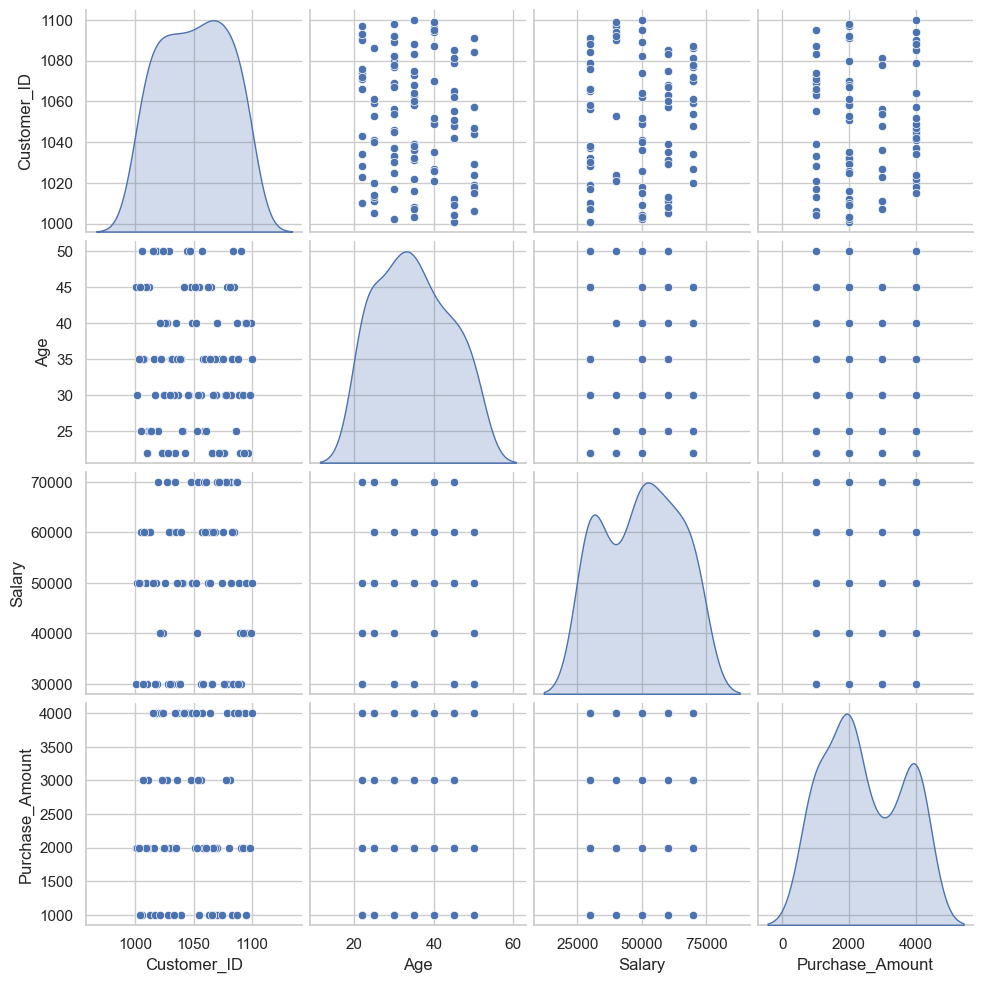

In [33]:
sns.set_theme(style="whitegrid")

# =============================================================
# 8. Perform Univariate Analysis (Ek variable ka distribution)
# =============================================================
print("Generating Univariate Plots...")

# Age, Income, aur Purchases ke liye subplots bana rahe hain
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Age Distribution
if 'Age' in df_csv.columns:
    sns.histplot(df_csv['Age'], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Distribution of Age')
    axes[0].set_xlabel('Age')

# Plot 2: Income Distribution
if 'Income' in df_csv.columns:
    sns.histplot(df_csv['Income'], kde=True, ax=axes[1], color='salmon')
    axes[1].set_title('Distribution of Income')
    axes[1].set_xlabel('Income')

# Plot 3: Purchases Distribution
if 'Purchases' in df_csv.columns:
    sns.histplot(df_csv['Purchases'], kde=True, ax=axes[2], color='lightgreen')
    axes[2].set_title('Distribution of Purchases')
    axes[2].set_xlabel('Purchases')

plt.tight_layout()
plt.show()

# =============================================================
# 9. Perform Bivariate Analysis (Do variables ke beech ka rishta)
# =============================================================
print("\nGenerating Bivariate Plots...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Relationship between Gender & Purchases
if 'Gender' in df_csv.columns and 'Purchases' in df_csv.columns:
    sns.boxplot(x='Gender', y='Purchases', data=df_csv, ax=axes[0], palette='pastel')
    axes[0].set_title('Gender vs Purchases')

# Plot 2: Relationship between Income & Churn
if 'Income' in df_csv.columns and 'Churn' in df_csv.columns:
    sns.boxplot(x='Churn', y='Income', data=df_csv, ax=axes[1], palette='Set2')
    axes[1].set_title('Income vs Churn Status')

plt.tight_layout()
plt.show()

# =============================================================
# 10. Perform Multivariate Analysis (Kayi variables ka interactions)
# =============================================================
print("\nGenerating Multivariate Plots...")

# Plot 1: Correlation Heatmap of all numerical variables
plt.figure(figsize=(8, 6))
# Sirf numerical columns select kar rahe hain heatmap ke liye
numerical_df = df_csv.select_dtypes(include=['float64', 'int64', 'int32'])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

# Plot 2: Pair plots to identify feature interactions
# Agar Churn column hai toh uske base par colors split honge (hue)
if 'Churn' in df_csv.columns:
    sns.pairplot(df_csv, hue='Churn', palette='bright', diag_kind='kde')
else:
    sns.pairplot(df_csv, diag_kind='kde')
plt.show()

=== CUSTOM DATA PROFILING REPORT ===

--- 1. DESCRIPTIVE STATISTICS ---


,Customer_ID,Age,Gender,City,Salary,Purchase_Amount,Is_Member,Purchase_Date
count,102.000000,102.000000,62,93,80.000000,78.000000,70,88
unique,NaN,NaN,2,4,NaN,NaN,2,83
top,NaN,NaN,Male,Mumbai,NaN,NaN,Yes,2023-11-21
freq,NaN,NaN,36,29,NaN,NaN,44,3
mean,1050.843137,34.780469,NaN,NaN,49625.000000,2448.717949,NaN,NaN
std,28.827498,8.933807,NaN,NaN,14447.088095,1146.960250,NaN,NaN
min,1001.000000,22.000000,NaN,NaN,30000.000000,1000.000000,NaN,NaN
25%,1026.250000,30.000000,NaN,NaN,37500.000000,2000.000000,NaN,NaN
50%,1051.500000,34.950980,NaN,NaN,50000.000000,2000.000000,NaN,NaN
75%,1074.750000,40.000000,NaN,NaN,60000.000000,4000.000000,NaN,NaN




--- 2. MISSING VALUES SUMMARY ---


,Missing Count,Percentage (%)
Customer_ID,0,0.000000
Age,0,0.000000
Gender,40,39.215686
City,9,8.823529
Salary,22,21.568627
Purchase_Amount,24,23.529412
Is_Member,32,31.372549
Purchase_Date,14,13.725490




--- 3. DATA QUALITY WARNINGS ---
No major data quality issues or warnings detected.


--- 4. CORRELATIONS ---


,Customer_ID,Age,Salary,Purchase_Amount
Customer_ID,1.000000,-0.094307,0.072471,0.060572
Age,-0.094307,1.000000,-0.028150,0.180154
Salary,0.072471,-0.028150,1.000000,0.015462
Purchase_Amount,0.060572,0.180154,0.015462,1.000000


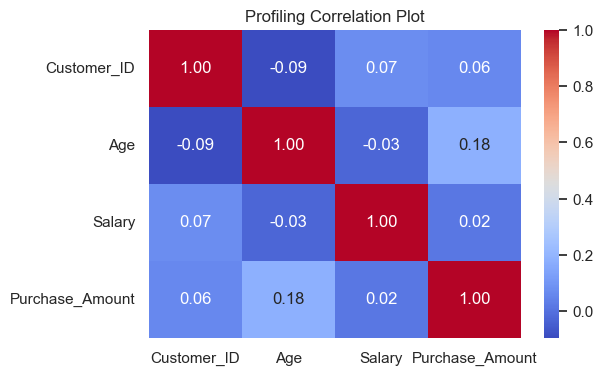

In [34]:
print("=== CUSTOM DATA PROFILING REPORT ===\n")

# 1. Descriptive Statistics
print("--- 1. DESCRIPTIVE STATISTICS ---")
# Isse aapko mean, median, min, max, std sab mil jayega
display(df_csv.describe(include='all'))
print("\n" + "="*50 + "\n")

# 2. Missing Values Summary
print("--- 2. MISSING VALUES SUMMARY ---")
missing_data = df_csv.isnull().sum()
missing_percent = (df_csv.isnull().sum() / len(df_csv)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_data, 'Percentage (%)': missing_percent})
display(missing_df)
print("\n" + "="*50 + "\n")

# 3. Warnings & Data Quality Issues
print("--- 3. DATA QUALITY WARNINGS ---")
has_warnings = False

# Warning for Zeroes
for col in df_csv.select_dtypes(include=['int64', 'float64']).columns:
    zero_count = (df_csv[col] == 0).sum()
    if zero_count > 0:
        print(col, f"has {zero_count} rows with value 0. Check if this is normal.")
        has_warnings = True

# Warning for Duplicates
duplicate_count = df_csv.duplicated().sum()
if duplicate_count > 0:
    print(f"⚠️ WARNING: Dataset has {duplicate_count} duplicate rows!")
    has_warnings = True

if not has_warnings:
    print("No major data quality issues or warnings detected.")
print("\n" + "="*50 + "\n")

# 4. Correlations Analysis
print("--- 4. CORRELATIONS ---")
numerical_df = df_csv.select_dtypes(include=['float64', 'int64', 'int32'])
if not numerical_df.empty:
    correlation_matrix = numerical_df.corr()
    display(correlation_matrix)
    
    # Iska matrix graphical view bhi show kar dete hain as per instructions
    plt.figure(figsize=(6, 4))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Profiling Correlation Plot")
    plt.show()
else:
    print("No numerical columns available for correlation analysis.")